# Combined figure-generation notebook

This notebook contains only the data preparation and plotting steps required to generate the requested figures. Run it from the directory containing the input files. All figures are saved directly in the current directory.


## Setup

The following cell imports the required packages, defines file locations, reconstructs the fixed hold-out split used by the outlier analysis, and loads the one-shot predictions required by the later outlier figures.


In [1]:
from pathlib import Path
from io import BytesIO
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from PIL import Image
from scipy.stats import pearsonr
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from rdkit import Chem, DataStructs
from rdkit.Chem import Draw, Descriptors, Lipinski, rdMolDescriptors, rdFingerprintGenerator
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Chem.Scaffolds import MurckoScaffold
from IPython.display import display
DATA_DIR = Path('.')
FIGURE_DIR = Path('.')
OUTPUT_DIR = Path('.')
SCAFFOLD_OUTPUT_DIR = Path('.')
SAVE_FIGURES = True
DPI = 300
SEED = 42
TOP_N = 50
FP_RADIUS = 2
FP_SIZE = 2048
CV_FILES = {'Model 1': 'model1_5x5CV.csv', 'Model 2': 'model2_5x5CV.csv', 'Model 3': 'model3_5x5CV.csv', 'Model 4': 'model4_5x5CV.csv', 'Model 4b': 'model4b_5x5CV.csv', 'Model 5': 'model5_5x5CV.csv', 'Model 6': 'model6_5x5CV.csv', 'Model 6b': 'model6b_5x5CV.csv'}
ONESHOT_FILES = {'XGBoost': 'XGBoost_oneshot.csv', 'Model 1': 'model1_oneshot.csv', 'Model 2': 'model2_oneshot.csv', 'Model 3': 'model3_oneshot.csv', 'Model 4': 'model4_oneshot.csv', 'Model 4b': 'model4b_oneshot.csv', 'Model 5': 'model5_oneshot.csv', 'Model 6': 'model6_oneshot.csv', 'Model 6b': 'model6b_oneshot.csv'}
EXTERNAL_FILES = {'Model 2': 'model2_external.csv', 'Model 4b': 'model4b_external.csv', 'Model 6b': 'model6b_external.csv'}

def require_columns(df, columns, filename):
    missing = [c for c in columns if c not in df.columns]
    if missing:
        raise ValueError(f'{filename}: missing required columns {missing}. Available columns: {list(df.columns)}')

def read_csv(filename, **kwargs):
    path = DATA_DIR / filename
    if not path.exists():
        raise FileNotFoundError(f'Required file not found: {path.resolve()}')
    return pd.read_csv(path, **kwargs)
OUTLIER_MODEL_FILES = {'Model1': 'model1_oneshot.csv', 'Model2': 'model2_oneshot.csv', 'Model3': 'model3_oneshot.csv', 'Model4': 'model4_oneshot.csv', 'Model4b': 'model4b_oneshot.csv', 'Model5': 'model5_oneshot.csv', 'Model6': 'model6_oneshot.csv', 'Model6b': 'model6b_oneshot.csv'}
aag_gap = pd.read_csv(DATA_DIR / 'AAG_adc2.csv')
aag_smiles = pd.read_csv(DATA_DIR / 'AAG_numbers_smiles.csv')
aag_adc2_data = aag_gap.merge(aag_smiles).astype({'Molecule': 'string', 'SMILES': 'string', 'dE(S0-S1)': 'float', 'dE(S0-T1)': 'float', 'dE(S1-T1)': 'float', 'f12(S0-S1)': 'float'})
train_cv_df, test_df = train_test_split(aag_adc2_data, test_size=0.2, shuffle=True, random_state=SEED)
train_cv_df, test_df = (train_cv_df.copy(), test_df.copy())
train_cv_df['dataset_index'] = train_cv_df.index
test_df['dataset_index'] = test_df.index
train_cv_df = train_cv_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
prediction_tables = {}
for model_name, filename in OUTLIER_MODEL_FILES.items():
    path = DATA_DIR / filename
    pred_df = pd.read_csv(path)
    unnamed = [c for c in pred_df.columns if c.startswith('Unnamed:')]
    if unnamed:
        pred_df = pred_df.drop(columns=unnamed)
    require_columns(pred_df, ['truevals', 'predvals'], str(path))
    pred_df['truevals'] = pd.to_numeric(pred_df['truevals'], errors='raise')
    pred_df['predvals'] = pd.to_numeric(pred_df['predvals'], errors='raise')
    if len(pred_df) != len(test_df):
        raise ValueError(f'{model_name}: {len(pred_df)} predictions but the reconstructed test set contains {len(test_df)} rows.')
    expected_true, observed_true = (test_df['dE(S1-T1)'].to_numpy(), pred_df['truevals'].to_numpy())
    if not np.allclose(observed_true, expected_true, rtol=0, atol=1e-07):
        raise ValueError(f'{model_name}: truevals order does not match the reconstructed test split.')
    combined = test_df.copy()
    combined['model'] = model_name
    combined['true_value'] = pred_df['truevals'].to_numpy()
    combined['pred_value'] = pred_df['predvals'].to_numpy()
    combined['signed_error'] = combined['pred_value'] - combined['true_value']
    combined['abs_error'] = combined['signed_error'].abs()
    prediction_tables[model_name] = combined
top_outliers = {}
for model_name, df in prediction_tables.items():
    top = df.sort_values('abs_error', ascending=False).head(TOP_N).copy().reset_index(drop=True)
    top.insert(0, 'outlier_rank', np.arange(1, len(top) + 1))
    top_outliers[model_name] = top


## 1. `fig1.png`

Predicted versus reference STG values for the nine one-shot models, including the reported error metrics.


model
Model 1     13739
Model 2     13739
Model 3     13739
Model 4     13739
Model 4b    13739
Model 5     13739
Model 6     13739
Model 6b    13739
XGBoost     13739
Name: n, dtype: int64

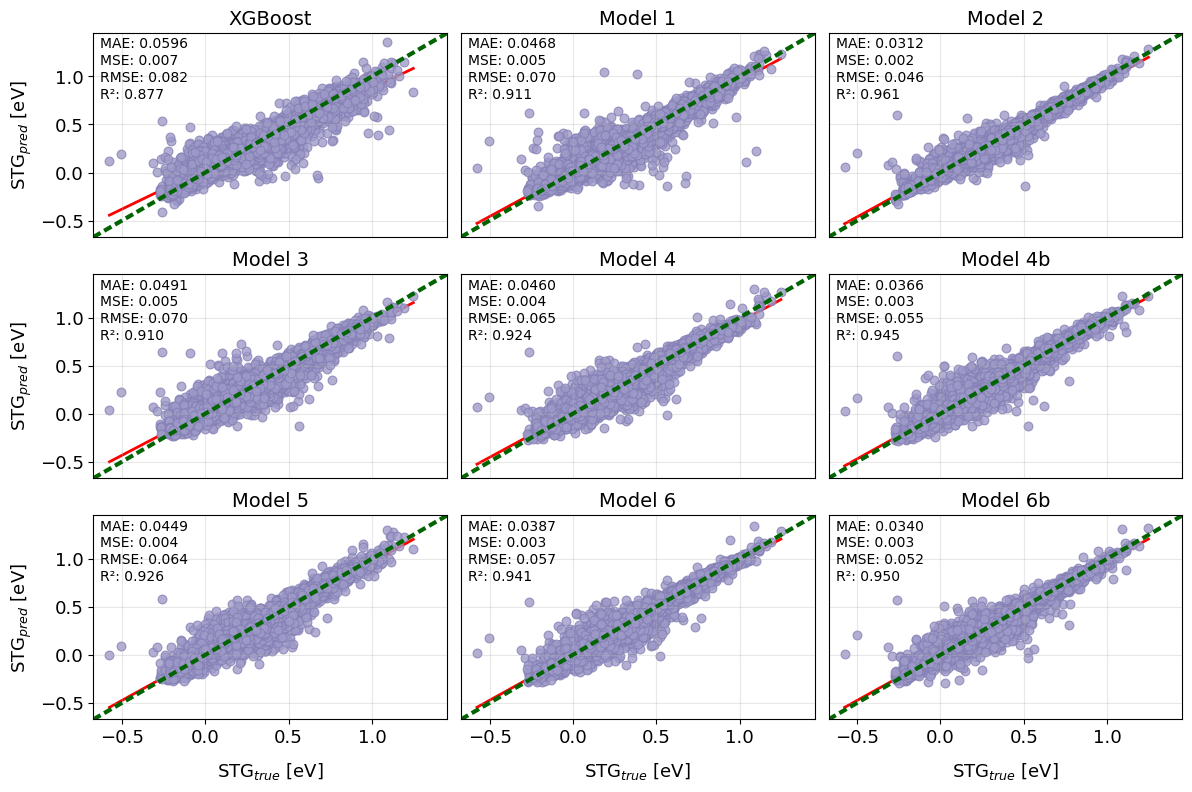

In [2]:
oneshot_parts = []
for model_name, filename in ONESHOT_FILES.items():
    df = read_csv(filename, index_col=0)
    require_columns(df, ['truevals', 'predvals'], filename)
    df = df.copy()
    df['model'] = model_name
    oneshot_parts.append(df)
oneshot_df = pd.concat(oneshot_parts, ignore_index=True)
display(oneshot_df.groupby('model').size().rename('n'))
model_order = list(ONESHOT_FILES.keys())
nrows, ncols = (3, 3)
color1, color1c, color2 = ('#9F9BC9', '#8580B5', 'darkgreen')
global_min = min(oneshot_df['truevals'].min(), oneshot_df['predvals'].min())
global_max = max(oneshot_df['truevals'].max(), oneshot_df['predvals'].max())
margin = 0.05 * (global_max - global_min)
global_min -= margin
global_max += margin
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 8), squeeze=False)
axes = axes.flatten()
for i, (ax, model) in enumerate(zip(axes, model_order)):
    sub = oneshot_df[oneshot_df['model'] == model]
    if sub.empty:
        ax.axis('off')
        continue
    x, y = (sub['truevals'].to_numpy(), sub['predvals'].to_numpy())
    slope, intercept = np.polyfit(x, y, 1)
    xx = np.linspace(x.min(), x.max(), 200)
    yy = slope * xx + intercept
    mae, mse, rmse, r2 = (mean_absolute_error(x, y), mean_squared_error(x, y), root_mean_squared_error(x, y), r2_score(x, y))
    ax.scatter(x, y, s=40, alpha=0.8, facecolor=color1, edgecolor=color1c, linewidth=0.8)
    ax.plot(xx, yy, linewidth=2, color='red', zorder=-3)
    ax.plot([global_min, global_max], [global_min, global_max], linestyle=(0, (2, 1)), linewidth=3, color=color2)
    ax.text(0.02, 0.98, f'MAE: {mae:.4f}\nMSE: {mse:.3f}\nRMSE: {rmse:.3f}\nR²: {r2:.3f}', transform=ax.transAxes, fontsize=10, linespacing=1.25, verticalalignment='top')
    ax.set_xlim(global_min, global_max)
    ax.set_ylim(global_min, global_max)
    ax.set_title(model, fontsize=14)
    ax.grid(alpha=0.3)
    row, col = (i // ncols, i % ncols)
    if row == nrows - 1:
        ax.set_xlabel('STG$_{true}$ [eV]', fontsize=13, labelpad=10)
        ax.tick_params(axis='x', labelsize=13)
    else:
        ax.set_xticklabels([])
        ax.tick_params(axis='x', which='both', length=0)
    if col == 0:
        ax.set_ylabel('STG$_{pred}$ [eV]', fontsize=13)
        ax.tick_params(axis='y', labelsize=13)
    else:
        ax.set_yticklabels([])
        ax.tick_params(axis='y', which='both', length=0)
for ax in axes[len(model_order):]:
    ax.axis('off')
plt.tight_layout(pad=1.0)
if SAVE_FIGURES:
    fig.savefig('fig1.png', dpi=DPI, bbox_inches='tight', pad_inches=0.05)
plt.show()


## 2. `fig2.png`

Overlap of the 50 largest-error test molecules identified by each production model, shown as an UpSet-style Matplotlib figure.


Total number of distinct outliers: 204
Total number of distinct model combinations: 59
Number of intersections shown in the figure: 25


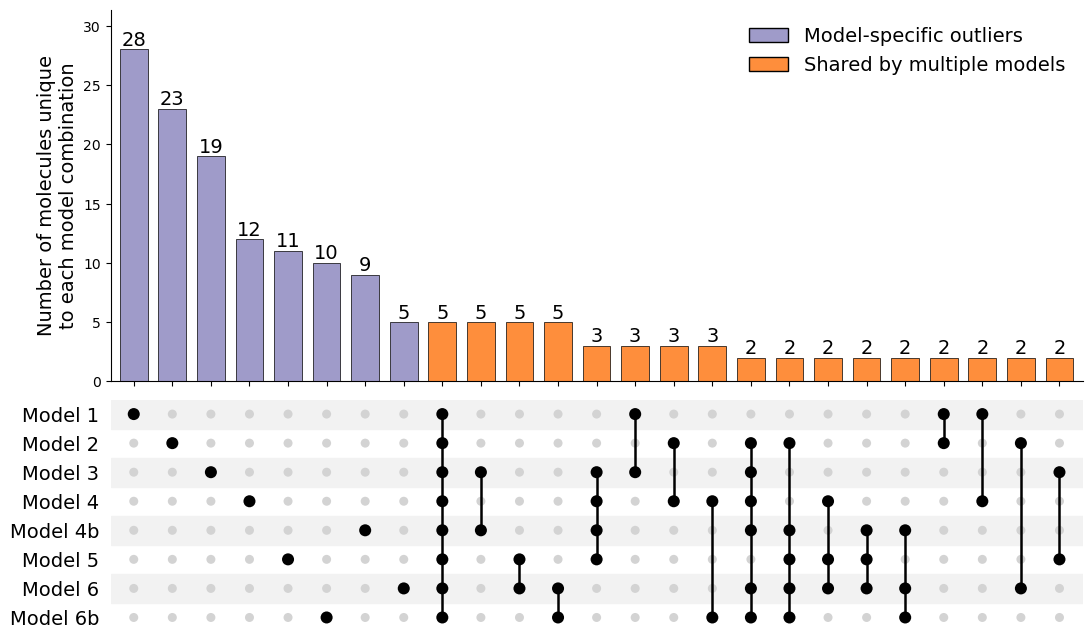

In [3]:
MAX_INTERSECTIONS = 25
MODEL_SPECIFIC_COLOR = 'tab:orange'
MODEL_SPECIFIC_COLOR = '#9F9BC9'
SHARED_COLOR = 'tab:blue'
SHARED_COLOR = '#FE8E3C'
ACTIVE_DOT_COLOR = 'black'
INACTIVE_DOT_COLOR = 'lightgray'
outlier_sets = {model_name: set(model_df['dataset_index'].astype(int)) for model_name, model_df in top_outliers.items()}
model_names = list(outlier_sets.keys())
MODEL_NAME_MAP = {'Model1': 'Model 1', 'Model2': 'Model 2', 'Model3': 'Model 3', 'Model4': 'Model 4', 'Model4b': 'Model 4b', 'Model5': 'Model 5', 'Model6': 'Model 6', 'Model6b': 'Model 6b'}
display_model_names = [MODEL_NAME_MAP.get(name, name) for name in model_names]
all_outlier_ids = sorted(set().union(*outlier_sets.values()))
membership_rows = []
for molecule_id in all_outlier_ids:
    membership = tuple((model_name for model_name in model_names if molecule_id in outlier_sets[model_name]))
    membership_rows.append({'dataset_index': molecule_id, 'membership': membership, 'degree': len(membership)})
membership_df = pd.DataFrame(membership_rows)
intersection_df = membership_df.groupby('membership', as_index=False).agg(intersection_size=('dataset_index', 'size'), degree=('degree', 'first'))
intersection_df['intersection_group'] = np.where(intersection_df['degree'] == 1, 0, 1)
intersection_df = intersection_df.sort_values(by=['intersection_group', 'intersection_size', 'degree'], ascending=[True, False, False]).reset_index(drop=True)
intersection_plot_df = intersection_df.head(MAX_INTERSECTIONS).copy()
print(f'Total number of distinct outliers: {len(all_outlier_ids)}')
print(f'Total number of distinct model combinations: {len(intersection_df)}')
print(f'Number of intersections shown in the figure: {len(intersection_plot_df)}')
n_intersections = len(intersection_plot_df)
n_models = len(model_names)
fig = plt.figure(figsize=(max(11, n_intersections * 0.48), 7.5))
grid = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[4.8, 3], hspace=0.06)
ax_intersections = fig.add_subplot(grid[0, 0])
ax_matrix = fig.add_subplot(grid[1, 0], sharex=ax_intersections)
x_positions = np.arange(n_intersections)
intersection_colors = [MODEL_SPECIFIC_COLOR if degree == 1 else SHARED_COLOR for degree in intersection_plot_df['degree']]
bars = ax_intersections.bar(x_positions, intersection_plot_df['intersection_size'], color=intersection_colors, edgecolor='black', linewidth=0.5, width=0.72)
for bar, value in zip(bars, intersection_plot_df['intersection_size']):
    ax_intersections.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(value), ha='center', va='bottom', fontsize=14)
ax_intersections.set_ylabel('Number of molecules unique\nto each model combination', fontsize=14)
ax_intersections.set_xticks([])
ax_intersections.spines['top'].set_visible(False)
ax_intersections.spines['right'].set_visible(False)
ax_intersections.set_xlim(-0.6, n_intersections - 0.4)
ax_intersections.margins(y=0.12)
for column_index, membership in enumerate(intersection_plot_df['membership']):
    active_rows = []
    for row_index, model_name in enumerate(model_names):
        is_active = model_name in membership
        ax_matrix.scatter(column_index, row_index, s=75 if is_active else 42, color=ACTIVE_DOT_COLOR if is_active else INACTIVE_DOT_COLOR, edgecolor='none', zorder=3)
        if is_active:
            active_rows.append(row_index)
    if len(active_rows) >= 2:
        ax_matrix.plot([column_index, column_index], [min(active_rows), max(active_rows)], color=ACTIVE_DOT_COLOR, linewidth=1.8, zorder=4)
for row_index in range(n_models):
    if row_index % 2 == 0:
        ax_matrix.axhspan(row_index - 0.5, row_index + 0.5, color='0.95', zorder=0)
ax_matrix.set_xlim(-0.6, n_intersections - 0.4)
ax_matrix.set_ylim(n_models - 0.5, -0.5)
ax_matrix.set_xticks(x_positions)
ax_matrix.set_xticklabels([])
ax_matrix.set_yticks(np.arange(n_models))
ax_matrix.set_yticklabels(display_model_names, fontsize=14)
ax_matrix.tick_params(axis='x', length=0)
ax_matrix.tick_params(axis='y', length=0, pad=8)
for spine in ax_matrix.spines.values():
    spine.set_visible(False)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=MODEL_SPECIFIC_COLOR, edgecolor='black', label='Model-specific outliers'), Patch(facecolor=SHARED_COLOR, edgecolor='black', label='Shared by multiple models')]
ax_intersections.legend(handles=legend_elements, frameon=False, loc='upper right', fontsize=14)
fig.subplots_adjust(left=0.17, right=0.98, top=0.91, bottom=0.08)
plt.savefig('fig2.png', dpi=600, bbox_inches='tight')
plt.show()


## 3. `fig3.png`

Tukey HSD comparison based on validation RMSE values from the 5×5 cross-validation results. XGBoost validation RMSE values are reconstructed from the 25 MSE values stored in the original notebook output.


,count,mean,std
model,,,
Model 1,25,0.071284,0.003551
Model 2,25,0.047976,0.003693
Model 3,25,0.072635,0.002834
Model 4,25,0.065373,0.005858
Model 4b,25,0.056630,0.002856
Model 5,25,0.062391,0.005506
Model 6,25,0.059697,0.003256
Model 6b,25,0.053627,0.002592
XGBoost,25,0.086179,0.001090


NOTE: XGBoost RMSE values are reconstructed from the 25 validation MSE values
stored in the original notebook output. Those MSE values were printed to 4 decimals,
so the reconstructed XGBoost RMSE values are approximate; no retraining is performed.
  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1   group2  meandiff p-adj   lower   upper  reject
--------------------------------------------------------
 Model 1  Model 2  -0.0233    0.0 -0.0266   -0.02   True
 Model 1  Model 3   0.0014 0.9365  -0.002  0.0047  False
 Model 1  Model 4  -0.0059    0.0 -0.0092 -0.0026   True
 Model 1 Model 4b  -0.0147    0.0  -0.018 -0.0113   True
 Model 1  Model 5  -0.0089    0.0 -0.0122 -0.0056   True
 Model 1  Model 6  -0.0116    0.0 -0.0149 -0.0083   True
 Model 1 Model 6b  -0.0177    0.0  -0.021 -0.0143   True
 Model 1  XGBoost   0.0149    0.0  0.0116  0.0182   True
 Model 2  Model 3   0.0247    0.0  0.0213   0.028   True
 Model 2  Model 4   0.0174    0.0  0.0141  0.0207   True
 Model 2 M

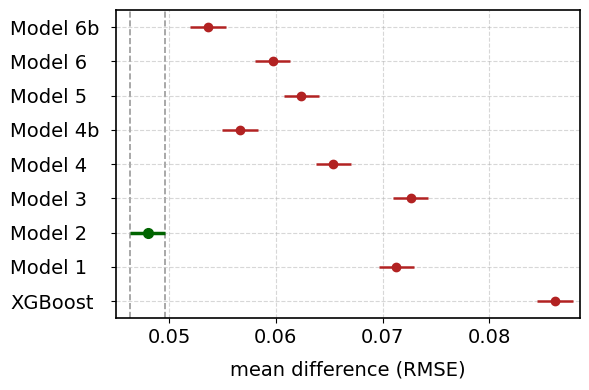

In [4]:
cv_parts = []
XGBOOST_VAL_MSE_FROM_NOTEBOOK = np.array([0.0076, 0.0075, 0.0075, 0.0074, 0.0074, 0.0073, 0.0075, 0.0076, 0.0075, 0.0072, 0.0071, 0.0072, 0.0074, 0.0076, 0.0076, 0.0079, 0.0072, 0.0075, 0.0072, 0.0072, 0.0074, 0.0075, 0.0077, 0.0074, 0.0073])
xgb = pd.DataFrame({'subset': 'valid', 'mse': XGBOOST_VAL_MSE_FROM_NOTEBOOK, 'rmse': np.sqrt(XGBOOST_VAL_MSE_FROM_NOTEBOOK), 'model': 'XGBoost'})
cv_parts.append(xgb)
for model_name, filename in CV_FILES.items():
    if model_name == 'XGBoost':
        continue
    df = read_csv(filename, index_col=0)
    require_columns(df, ['subset', 'rmse'], filename)
    df = df.query("subset == 'valid'").copy()
    df['model'] = model_name
    cv_parts.append(df)
final_CV = pd.concat(cv_parts, ignore_index=True)
display(final_CV.groupby('model')['rmse'].agg(['count', 'mean', 'std']))
print('NOTE: XGBoost RMSE values are reconstructed from the 25 validation MSE values')
print('stored in the original notebook output. Those MSE values were printed to 4 decimals,')
print('so the reconstructed XGBoost RMSE values are approximate; no retraining is performed.')
tukey = pairwise_tukeyhsd(endog=final_CV['rmse'], groups=final_CV['model'], alpha=0.05)
print(tukey)
group_names = list(tukey.groupsunique)
means = np.asarray(tukey._multicomp.groupstats.groupmean)
if getattr(tukey, 'halfwidths', None) is None:
    tukey._simultaneous_ci()
halfwidths = np.asarray(tukey.halfwidths)
xgb_idx = group_names.index('XGBoost')
order = [xgb_idx] + [i for i in range(len(group_names)) if i != xgb_idx]
group_names = [group_names[i] for i in order]
means = means[order]
halfwidths = halfwidths[order]
ypos = np.arange(len(group_names))
model2_idx = group_names.index('Model 2')
fig, ax = plt.subplots(figsize=(6, 4))
for i, (name, mean, hw) in enumerate(zip(group_names, means, halfwidths)):
    if name == 'Model 2':
        color = 'forestgreen'
        color = 'darkgreen'
        linewidth = 2.5
        markersize = 7
        zorder = 3
    else:
        color = 'mediumpurple'
        color = 'royalblue'
        color = 'palevioletred'
        color = 'firebrick'
        linewidth = 1.8
        markersize = 6
        zorder = 2
    ax.errorbar(mean, ypos[i], xerr=hw, fmt='o', color=color, ecolor=color, markersize=markersize, linewidth=linewidth, elinewidth=linewidth, capsize=0, zorder=zorder)
mean_model2 = means[model2_idx]
hw_model2 = halfwidths[model2_idx]
ci_low = mean_model2 - hw_model2
ci_high = mean_model2 + hw_model2
ax.axvline(ci_low, color='gray', linestyle='--', linewidth=1.2, alpha=0.8, zorder=1)
ax.axvline(ci_high, color='gray', linestyle='--', linewidth=1.2, alpha=0.8, zorder=1)
ax.set_yticks(ypos)
ax.set_yticklabels(group_names)
ax.set_xlabel('mean difference (RMSE)', fontsize=14, labelpad=10)
ax.tick_params(axis='both', labelsize=14)
ax.tick_params(axis='y', pad=6)
for label in ax.get_yticklabels():
    label.set_horizontalalignment('left')
    label.set_x(-0.2)
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_xlim(0.045, 0.0885)
ax.set_ylim(-0.5, len(group_names) - 0.5)
for spine in ax.spines.values():
    spine.set_linewidth(1.2)
plt.tight_layout()
if SAVE_FIGURES:
    fig.savefig(Path('.') / 'fig3.png', dpi=DPI, bbox_inches='tight', pad_inches=0.05)
plt.show()


## 4. `fig4.png`

Predicted versus reference STG values for Models 2, 4b, and 6b on the external set.


model
Model 2     59
Model 4b    59
Model 6b    59
Name: n, dtype: int64

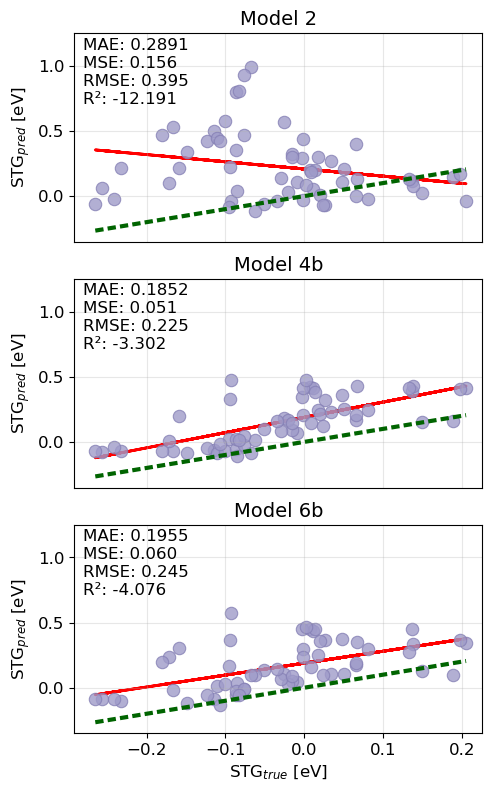

In [5]:
external_parts = []
for model_name, filename in EXTERNAL_FILES.items():
    df = read_csv(filename, index_col=0)
    require_columns(df, ['truevals', 'predvals'], filename)
    df = df.copy()
    df['model'] = model_name
    external_parts.append(df)
external_pred_df = pd.concat(external_parts, ignore_index=True)
display(external_pred_df.groupby('model').size().rename('n'))
models = external_pred_df['model'].unique()
n = len(models)
color1 = '#9F9BC9'
color1c = '#8580B5'
color2 = 'darkgreen'
global_xmin = external_pred_df['truevals'].min() * 1.1
global_xmax = external_pred_df['truevals'].max() * 1.1
fig, axes = plt.subplots(3, 1, figsize=(5, 8))
axes = axes.flatten()
for i, (ax, model) in enumerate(zip(axes, models)):
    sub = external_pred_df[external_pred_df['model'] == model]
    x = sub['truevals'].values
    y = sub['predvals'].values
    slope, intercept = np.polyfit(x, y, 1)
    reg_line = slope * x + intercept
    mae = mean_absolute_error(x, y)
    rmse = root_mean_squared_error(x, y)
    mse = mean_squared_error(x, y)
    r2 = r2_score(x, y)
    ax.scatter(x, y, s=80, alpha=0.8, facecolor=color1, edgecolor=color1c, linewidth=0.8)
    ax.plot(x, reg_line, linewidth=2, color='red', zorder=-3)
    ax.plot([x.min(), x.max()], [x.min(), x.max()], color=color2, linestyle=(0, (2, 1)), linewidth=3)
    ax.text(0.02, 0.98, f'MAE: {mae:.4f}\nMSE: {mse:.3f}\nRMSE: {rmse:.3f}\nR²: {r2:.3f}', transform=ax.transAxes, fontsize=12, linespacing=1.25, verticalalignment='top')
    ax.set_xlim(global_xmin, global_xmax)
    ax.set_ylim(-0.35, 1.25)
    ax.tick_params(axis='y', labelsize=12)
    ax.set_title(model, size=14)
    if i in (0, 1):
        ax.set_xlabel('')
        ax.set_xticklabels([])
        ax.tick_params(axis='x', which='both', length=0)
        ax.set_ylabel('STG$_{pred}$ [eV]', size=12)
    else:
        ax.set_xlabel('STG$_{true}$ [eV]', size=12)
        ax.set_ylabel('STG$_{pred}$ [eV]', size=12)
        ax.tick_params(axis='x', labelsize=12)
    ax.grid(alpha=0.3)
for ax in axes[n:]:
    ax.axis('off')
plt.tight_layout(pad=1.0)
plt.savefig('fig4.png', bbox_inches='tight', pad_inches=0.05)
plt.show()


## 5. `fig5.png`

Absolute external-set STG error as a function of mean top-5 structural similarity, with a linear fit and Pearson correlation for each model.


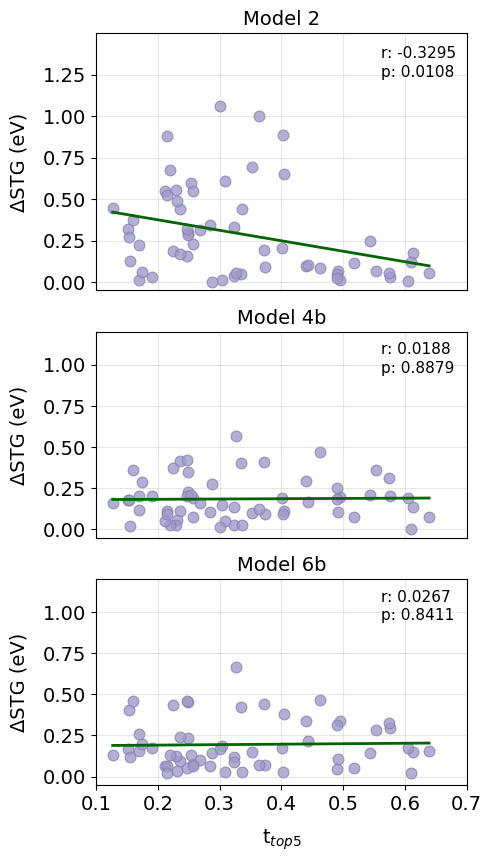

In [6]:
ext_fulldf = pd.read_csv(DATA_DIR / 'externals_allinone.csv', index_col=0)
required = ['SMILES', 'STG', 'top5_sim', 'model2_predvals', 'model4b_predvals', 'model6b_predvals']
require_columns(ext_fulldf, required, 'externals_allinone.csv')
x = ext_fulldf['top5_sim'].to_numpy()
truevals = ext_fulldf['STG'].to_numpy()
color1, color1c, color2 = '#9F9BC9', '#8580B5', 'darkgreen'
models = [('Model 2', 'model2_predvals'), ('Model 4b', 'model4b_predvals'), ('Model 6b', 'model6b_predvals')]
fig, axes = plt.subplots(3, 1, figsize=(5, 8.7), gridspec_kw={'height_ratios': [1.25, 1, 1]})
axes = np.atleast_1d(axes).flatten()
for i, (ax, (model_label, pred_col)) in enumerate(zip(axes, models)):
    predvals = ext_fulldf[pred_col].to_numpy()
    y = np.abs(predvals - truevals)
    slope, intercept = np.polyfit(x, y, 1)
    xx = np.linspace(x.min(), x.max(), 200)
    yy = slope * xx + intercept
    r, p = pearsonr(x, y)
    ax.scatter(x, y, s=60, alpha=0.8, facecolor=color1, edgecolor=color1c, linewidth=0.8)
    ax.plot(xx, yy, linewidth=2, color=color2, zorder=2)
    ax.tick_params(axis='y', labelsize=14)
    ax.text(0.77, 0.95, f'r: {r:.4f}\np: {p:.4f}', transform=ax.transAxes, fontsize=11, linespacing=1.3, verticalalignment='top')
    ax.set_xlim(0.1, 0.7)
    if i == 0:
        ax.set_ylim(-0.05, 1.5)
        ax.set_yticks(np.arange(0, 1.26, 0.25))
    else:
        ax.set_ylim(-0.05, 1.2)
    ax.set_title(model_label, fontsize=14)
    ax.set_ylabel('ΔSTG (eV)', fontsize=14, labelpad=10)
    ax.grid(alpha=0.3)
    if i < 2:
        ax.set_xticklabels([])
        ax.tick_params(axis='x', which='both', length=0)
    else:
        ax.set_xlabel('t$_{top5}$', fontsize=14, labelpad=10)
        ax.tick_params(axis='x', labelsize=14)
plt.tight_layout(pad=1.0)
if SAVE_FIGURES:
    fig.savefig('fig5.png', dpi=DPI, bbox_inches='tight', pad_inches=0.05)
plt.show()


## 6. `figs1.png`

Distribution of how many models identify the same test molecule among their 50 largest prediction errors.


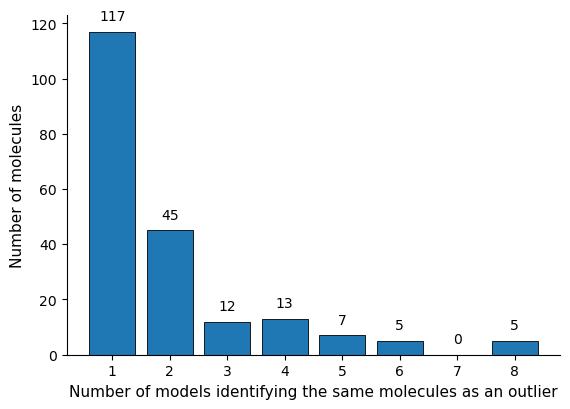

In [7]:
membership_rows = []
for model_name, top_df in top_outliers.items():
    for _, row in top_df.iterrows():
        membership_rows.append({'dataset_index': int(row['dataset_index']), 'Molecule': row['Molecule'], 'SMILES': row['SMILES'], 'model': model_name, 'rank': int(row['outlier_rank']), 'abs_error': float(row['abs_error']), 'signed_error': float(row['signed_error']), 'true_value': float(row['true_value']), 'pred_value': float(row['pred_value'])})
membership_long = pd.DataFrame(membership_rows)
common_outliers = membership_long.groupby(['dataset_index', 'Molecule', 'SMILES'], as_index=False).agg(n_models=('model', 'nunique'), models=('model', lambda x: ', '.join(sorted(set(x)))), best_rank=('rank', 'min'), mean_rank=('rank', 'mean'), mean_abs_error=('abs_error', 'mean'), max_abs_error=('abs_error', 'max'), mean_signed_error=('signed_error', 'mean')).sort_values(['n_models', 'mean_abs_error'], ascending=[False, False])
frequency = common_outliers['n_models'].value_counts().reindex(range(common_outliers['n_models'].min(), common_outliers['n_models'].max() + 1), fill_value=0)
fig, ax = plt.subplots(figsize=(5.8, 4.2))
bars = ax.bar(frequency.index.astype(str), frequency.values, color='tab:blue', edgecolor='black', linewidth=0.6)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3, f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=10)
ax.set_xlabel('Number of models identifying the same molecules as an outlier', fontsize=11)
ax.set_ylabel('Number of molecules', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('figs1.png', dpi=600, bbox_inches='tight')
plt.show()


## 7. `figs3.png`

Nine RDKit descriptor distributions comparing the 50 largest-error molecules with the 50 best-predicted control molecules for each model.


Calculated descriptor table: (13739, 17)


,MolWt,HeavyAtomCount,HeteroAtomCount,HeteroAtomFraction,AromaticAtomCount,AromaticAtomFraction,RingCount,AromaticRingCount,AliphaticRingCount,RotatableBondCount,HBA,HBD,TPSA,FractionCSP3,FormalCharge,NumFragments,dataset_index
0,236.238,18,6,0.333333,14,0.777778,3,0,3,0,6,2,114.50,0.0,0,1,51332
1,254.252,20,4,0.200000,14,0.700000,3,3,0,0,4,0,84.26,0.0,0,1,37762
2,251.253,19,7,0.368421,14,0.736842,3,0,3,0,7,3,140.52,0.0,0,1,63452
3,277.251,21,9,0.428571,14,0.666667,3,0,3,0,9,3,177.20,0.0,0,1,51648
4,301.273,23,9,0.391304,14,0.608696,3,0,3,0,9,3,188.10,0.0,0,1,50632


Best-predicted control groups prepared for each model.


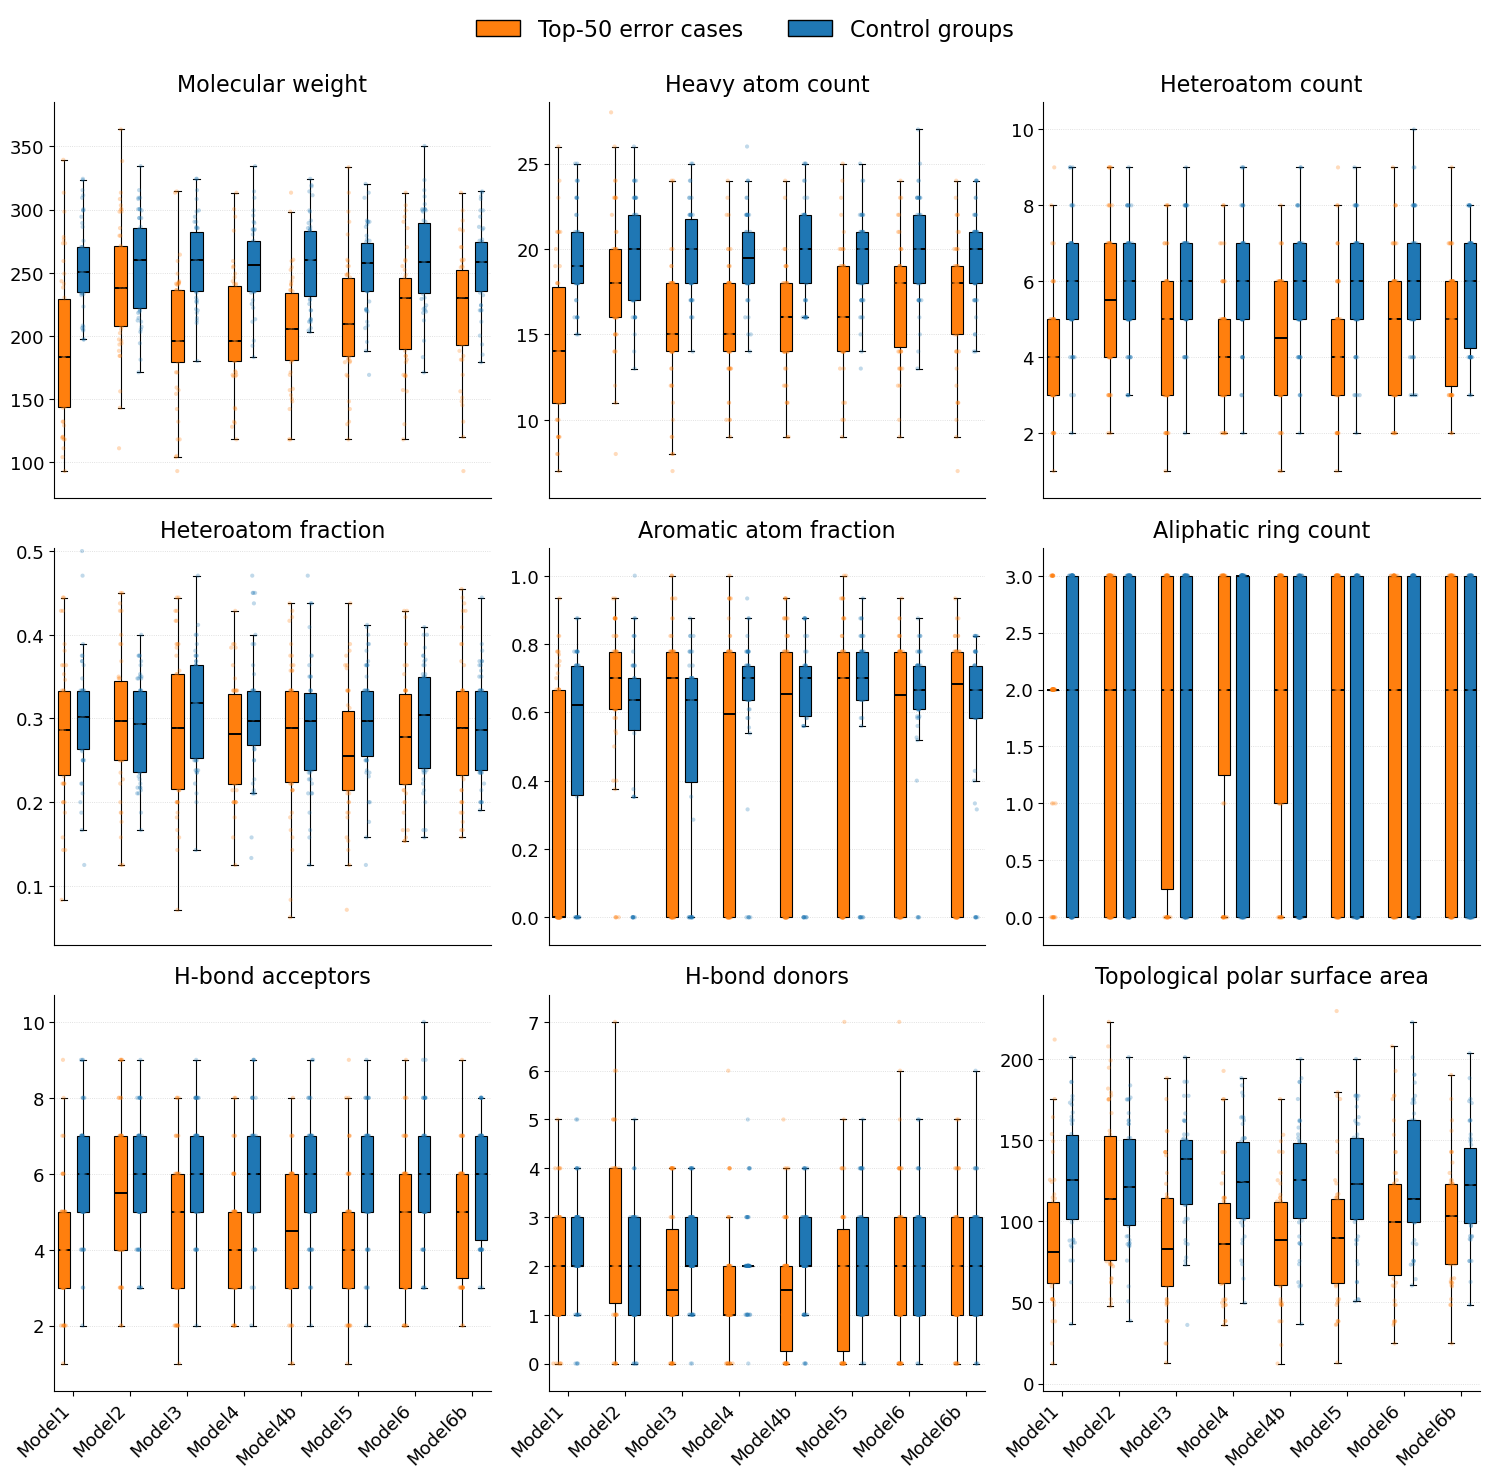

In [8]:
descriptor_rows = []
for _, row in test_df.iterrows():
    mol = Chem.MolFromSmiles(str(row['SMILES']))
    if mol is None:
        continue
    heavy_atoms = mol.GetNumHeavyAtoms()
    aromatic_atoms = sum((atom.GetIsAromatic() for atom in mol.GetAtoms()))
    hetero_atoms = sum((atom.GetAtomicNum() not in (1, 6) for atom in mol.GetAtoms()))
    formal_charge = sum((atom.GetFormalCharge() for atom in mol.GetAtoms()))
    desc = {'MolWt': Descriptors.MolWt(mol), 'HeavyAtomCount': heavy_atoms, 'HeteroAtomCount': hetero_atoms, 'HeteroAtomFraction': hetero_atoms / heavy_atoms if heavy_atoms else np.nan, 'AromaticAtomCount': aromatic_atoms, 'AromaticAtomFraction': aromatic_atoms / heavy_atoms if heavy_atoms else np.nan, 'RingCount': Lipinski.RingCount(mol), 'AromaticRingCount': Lipinski.NumAromaticRings(mol), 'AliphaticRingCount': Lipinski.NumAliphaticRings(mol), 'RotatableBondCount': Lipinski.NumRotatableBonds(mol), 'HBA': Lipinski.NumHAcceptors(mol), 'HBD': Lipinski.NumHDonors(mol), 'TPSA': rdMolDescriptors.CalcTPSA(mol), 'FractionCSP3': rdMolDescriptors.CalcFractionCSP3(mol), 'FormalCharge': formal_charge, 'NumFragments': len(Chem.GetMolFrags(mol)), 'dataset_index': int(row['dataset_index'])}
    descriptor_rows.append(desc)
descriptor_df = pd.DataFrame(descriptor_rows)
print('Calculated descriptor table:', descriptor_df.shape)
display(descriptor_df.head())
best_predicted = {}
for model_name, df in prediction_tables.items():
    best = df.sort_values('abs_error', ascending=True).head(TOP_N).copy().reset_index(drop=True)
    best.insert(0, 'control_rank', np.arange(1, len(best) + 1))
    best_predicted[model_name] = best
print('Best-predicted control groups prepared for each model.')
DESCRIPTORS = [('MolWt', 'Molecular weight'), ('HeavyAtomCount', 'Heavy atom count'), ('HeteroAtomCount', 'Heteroatom count'), ('HeteroAtomFraction', 'Heteroatom fraction'), ('AromaticAtomFraction', 'Aromatic atom fraction'), ('AliphaticRingCount', 'Aliphatic ring count'), ('HBA', 'H-bond acceptors'), ('HBD', 'H-bond donors'), ('TPSA', 'Topological polar surface area')]
if 'dataset_index' not in descriptor_df.columns:
    raise KeyError('descriptor_df does not contain a dataset_index column.')
descriptor_df_plot = descriptor_df.copy()
descriptor_df_plot['dataset_index'] = pd.to_numeric(descriptor_df_plot['dataset_index'], errors='coerce')
descriptor_df_plot = descriptor_df_plot.dropna(subset=['dataset_index']).drop_duplicates(subset='dataset_index')
descriptor_df_plot['dataset_index'] = descriptor_df_plot['dataset_index'].astype(int)
missing_descriptors = [descriptor for descriptor, _ in DESCRIPTORS if descriptor not in descriptor_df_plot.columns]
if missing_descriptors:
    raise KeyError('Missing descriptors: ' + ', '.join(missing_descriptors))

def get_descriptor_values(selection_df, descriptor):
    selected_ids = selection_df[['dataset_index']].copy()
    selected_ids['dataset_index'] = pd.to_numeric(selected_ids['dataset_index'], errors='coerce')
    selected_ids = selected_ids.dropna(subset=['dataset_index'])
    selected_ids['dataset_index'] = selected_ids['dataset_index'].astype(int)
    merged = selected_ids.merge(descriptor_df_plot[['dataset_index', descriptor]], on='dataset_index', how='left')
    values = pd.to_numeric(merged[descriptor], errors='coerce')
    values = values[np.isfinite(values)]
    return values.to_numpy(dtype=float)
OUTLIER_COLOR = 'tab:orange'
CONTROL_COLOR = 'tab:blue'
fig, axes = plt.subplots(3, 3, figsize=(15, 15), sharex=False, sharey=False)
axes = axes.ravel()
rng = np.random.default_rng(42)
fs = 16
for panel_index, (ax, (descriptor, title)) in enumerate(zip(axes, DESCRIPTORS)):
    box_data = []
    positions = []
    position = 1
    for model in model_names:
        outlier_values = get_descriptor_values(top_outliers[model], descriptor)
        control_values = get_descriptor_values(best_predicted[model], descriptor)
        box_data.extend([outlier_values, control_values])
        positions.extend([position, position + 1])
        position += 3
    bp = ax.boxplot(box_data, positions=positions, widths=0.65, patch_artist=True, showfliers=False, medianprops={'color': 'black', 'linewidth': 1.4}, whiskerprops={'color': 'black', 'linewidth': 0.8}, capprops={'color': 'black', 'linewidth': 0.8})
    for i, box in enumerate(bp['boxes']):
        if i % 2 == 0:
            box.set_facecolor(OUTLIER_COLOR)
        else:
            box.set_facecolor(CONTROL_COLOR)
        box.set_edgecolor('black')
        box.set_linewidth(0.8)
    for i, values in enumerate(box_data):
        if len(values) == 0:
            continue
        jittered_x = rng.normal(loc=positions[i], scale=0.06, size=len(values))
        point_color = OUTLIER_COLOR if i % 2 == 0 else CONTROL_COLOR
        ax.scatter(jittered_x, values, s=9, alpha=0.28, color=point_color, edgecolors='none', zorder=3)
    ax.relim()
    ax.autoscale_view(scalex=False, scaley=True)
    ax.margins(y=0.08)
    ax.set_title(title, fontsize=fs, pad=8)
    model_centers = [1.5 + 3 * i for i in range(len(model_names))]
    ax.set_xticks(model_centers)
    if panel_index >= 6:
        ax.set_xticklabels(model_names, rotation=45, ha='right', fontsize=fs)
        ax.tick_params(axis='x', labelsize=13)
    else:
        ax.set_xticklabels([])
        ax.tick_params(axis='x', length=0)
    ax.tick_params(axis='y', labelsize=13)
    ax.grid(axis='y', linestyle=':', linewidth=0.6, alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
legend_handles = [Patch(facecolor=OUTLIER_COLOR, edgecolor='black', label=f'Top-{TOP_N} error cases'), Patch(facecolor=CONTROL_COLOR, edgecolor='black', label=f'Control groups')]
fig.legend(handles=legend_handles, ncol=2, loc='upper center', bbox_to_anchor=(0.5, 0.99), frameon=False, fontsize=fs)
fig.tight_layout(rect=[0, 0, 1, 0.95], w_pad=1.0, h_pad=1.5)
fig.savefig(OUTPUT_DIR / 'figs3.png', dpi=600, bbox_inches='tight')
plt.show()


## 8. `figs4.png`

For each bottom-50 molecule, the mean Tanimoto similarity to its five nearest Train-CV analogues is calculated and summarized by model.


Train-CV molecules with fingerprints: 54956


,model,n_molecules,mean,median,minimum,maximum
0,Model1,50,0.666324,0.665387,0.535238,0.832019
1,Model2,50,0.696361,0.696859,0.567661,0.835191
2,Model3,50,0.650488,0.654551,0.460476,0.786667
3,Model4,50,0.668026,0.671326,0.535238,0.823375
4,Model4b,50,0.652253,0.665234,0.460476,0.752379
5,Model5,50,0.668051,0.669340,0.535238,0.905298
6,Model6,50,0.668836,0.673546,0.535238,0.823375
7,Model6b,50,0.676721,0.687190,0.536001,0.777346


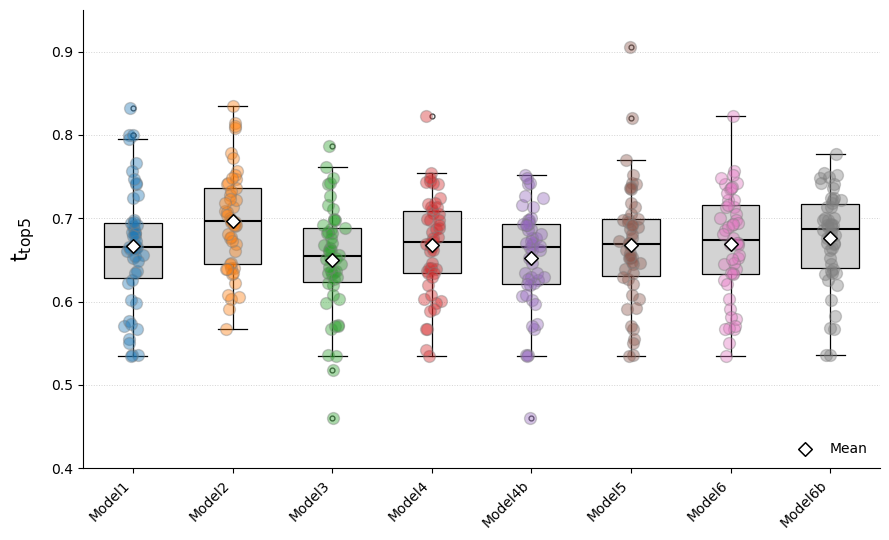

In [9]:
fp_generator = rdFingerprintGenerator.GetMorganGenerator(radius=FP_RADIUS, fpSize=FP_SIZE)
train_mols = []
train_fps = []
valid_train_rows = []
for row_pos, row in train_cv_df.iterrows():
    mol = Chem.MolFromSmiles(str(row['SMILES']))
    if mol is None:
        continue
    train_mols.append(mol)
    train_fps.append(fp_generator.GetFingerprint(mol))
    valid_train_rows.append(row_pos)
valid_train_df = train_cv_df.iloc[valid_train_rows].reset_index(drop=True)
print('Train-CV molecules with fingerprints:', len(valid_train_df))
within_model_neighbor_rows = []
for model_name in model_names:
    for _, outlier in top_outliers[model_name].iterrows():
        mol = Chem.MolFromSmiles(str(outlier['SMILES']))
        if mol is None:
            continue
        query_fp = fp_generator.GetFingerprint(mol)
        similarities = np.asarray(DataStructs.BulkTanimotoSimilarity(query_fp, train_fps))
        best_positions = np.argsort(similarities)[::-1][:5]
        for rank, pos in enumerate(best_positions, start=1):
            train_row = valid_train_df.iloc[pos]
            train_target = float(train_row['dE(S1-T1)'])
            within_model_neighbor_rows.append({'model': model_name, 'outlier_rank': int(outlier['outlier_rank']), 'outlier_dataset_index': int(outlier['dataset_index']), 'outlier_SMILES': outlier['SMILES'], 'outlier_true_value': float(outlier['true_value']), 'outlier_pred_value': float(outlier['pred_value']), 'outlier_abs_error': float(outlier['abs_error']), 'neighbor_rank': rank, 'train_dataset_index': int(train_row['dataset_index']), 'train_Molecule': train_row['Molecule'], 'train_SMILES': train_row['SMILES'], 'train_target': train_target, 'tanimoto': float(similarities[pos]), 'target_difference_from_neighbor': float(outlier['true_value']) - train_target, 'absolute_target_difference_from_neighbor': abs(float(outlier['true_value']) - train_target)})
within_model_neighbors = pd.DataFrame(within_model_neighbor_rows)

TOP_K_NEIGHBORS = 5
top5_neighbors = within_model_neighbors.loc[within_model_neighbors['neighbor_rank'].between(1, TOP_K_NEIGHBORS)].copy()
neighbor_counts = top5_neighbors.groupby(['model', 'outlier_dataset_index']).size()
if not (neighbor_counts == TOP_K_NEIGHBORS).all():
    problematic = neighbor_counts[neighbor_counts != TOP_K_NEIGHBORS]
    print(f'Warning: some molecules do not have exactly {TOP_K_NEIGHBORS} neighbors are assigned:')
    display(problematic)
top5_mean_by_molecule = top5_neighbors.groupby(['model', 'outlier_dataset_index'], as_index=False).agg(mean_top5_tanimoto=('tanimoto', 'mean'), n_neighbors=('tanimoto', 'count'))
top5_mean_by_molecule = top5_mean_by_molecule.loc[top5_mean_by_molecule['n_neighbors'] == TOP_K_NEIGHBORS].copy()
plot_models = [model for model in model_names if model in top5_mean_by_molecule['model'].unique()]
tanimoto_by_model = [top5_mean_by_molecule.loc[top5_mean_by_molecule['model'] == model, 'mean_top5_tanimoto'].to_numpy() for model in plot_models]
summary = top5_mean_by_molecule.groupby('model', as_index=False).agg(n_molecules=('outlier_dataset_index', 'nunique'), mean=('mean_top5_tanimoto', 'mean'), median=('mean_top5_tanimoto', 'median'), minimum=('mean_top5_tanimoto', 'min'), maximum=('mean_top5_tanimoto', 'max'))
display(summary)
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.boxplot(tanimoto_by_model, tick_labels=plot_models, patch_artist=True, showfliers=True, widths=0.58, medianprops={'color': 'black', 'linewidth': 1.5}, boxprops={'facecolor': 'lightgray', 'edgecolor': 'black', 'linewidth': 0.9}, whiskerprops={'color': 'black', 'linewidth': 0.9}, capprops={'color': 'black', 'linewidth': 0.9}, flierprops={'marker': 'o', 'markersize': 3.5, 'markerfacecolor': 'white', 'markeredgecolor': 'black', 'alpha': 0.7})
rng = np.random.default_rng(42)
for position, values in enumerate(tanimoto_by_model, start=1):
    jittered_x = rng.normal(loc=position, scale=0.045, size=len(values))
    ax.scatter(jittered_x, values, s=73, alpha=0.4, edgecolors='grey', zorder=3)
model_means = [np.mean(values) for values in tanimoto_by_model]
ax.scatter(range(1, len(plot_models) + 1), model_means, marker='D', s=48, facecolor='white', edgecolor='black', linewidth=1.1, zorder=5, label='Mean')
ax.set_ylabel('$\\mathrm{t_{top5}}$', fontsize=16, labelpad=10)
ax.set_ylim(0.4, 0.95)
ax.set_xticklabels(plot_models, rotation=45, ha='right')
ax.grid(axis='y', linestyle=':', linewidth=0.7, alpha=0.55)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False, loc='lower right')
fig.tight_layout()
fig.savefig('figs4.png', dpi=600, bbox_inches='tight')
plt.show()


## 9. `figs5.png`

Nearest-neighbour similarity is plotted against the absolute target-value difference for each bottom-50 prediction; points meeting the operational property-cliff thresholds are highlighted.


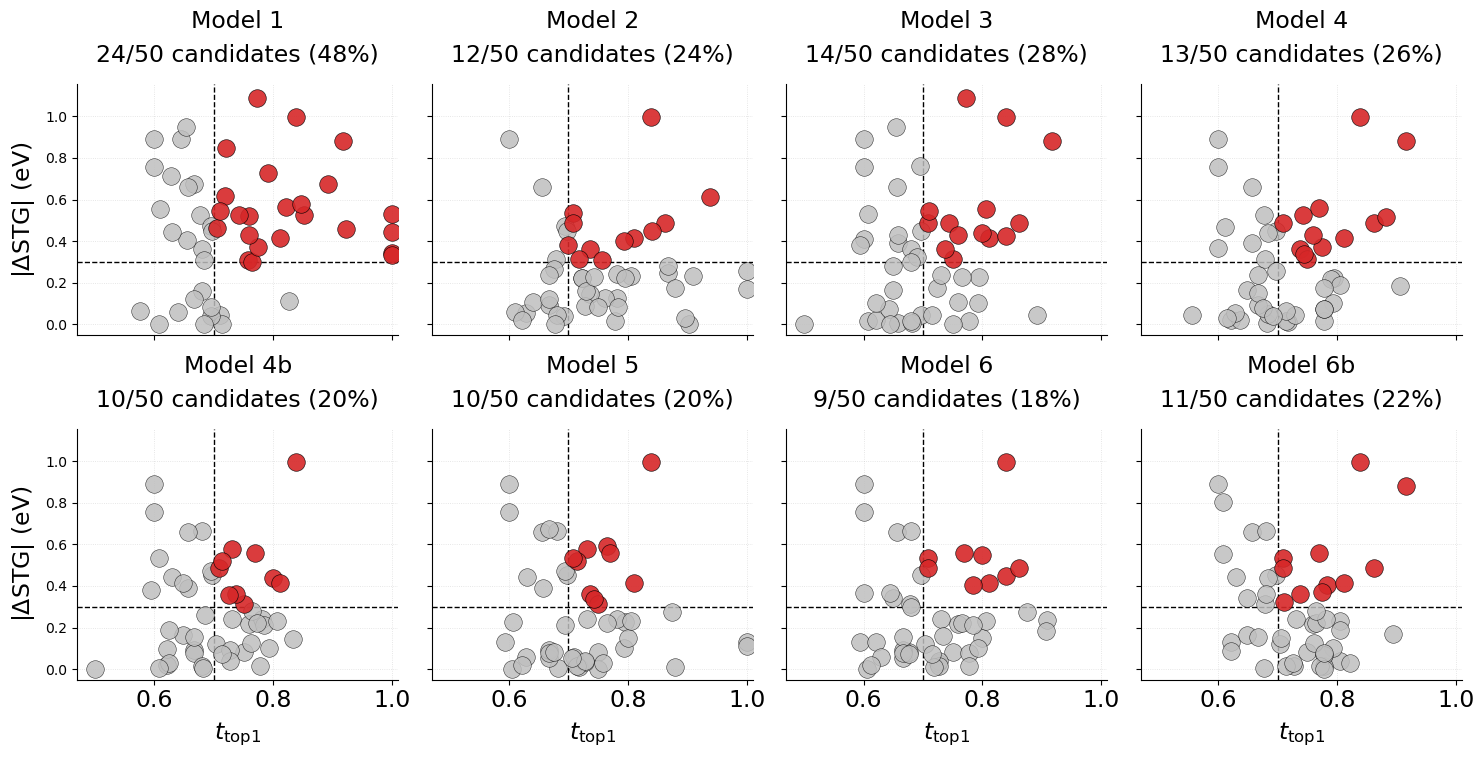

In [10]:
nearest_only = within_model_neighbors.loc[within_model_neighbors['neighbor_rank'] == 1].copy()
PROPERTY_CLIFF_TANIMOTO = 0.7
PROPERTY_CLIFF_TARGET_GAP = 0.3
plot_df = nearest_only.copy()
plot_models = [model for model in model_names if model in plot_df['model'].unique()]
x_min = max(0.0, plot_df['tanimoto'].min() - 0.03)
x_max = 1.01
y_min = -0.05
size = 160
fs = 17
fst = 14
lsp = 1.6
y_max = plot_df['absolute_target_difference_from_neighbor'].max() * 1.06
fig, axes = plt.subplots(2, 4, figsize=(15.5, 8.0), sharex=True, sharey=True)
axes = axes.ravel()
for ax, model in zip(axes, plot_models):
    model_df = plot_df.loc[plot_df['model'] == model].copy()
    cliff_mask = (model_df['tanimoto'] >= PROPERTY_CLIFF_TANIMOTO) & (model_df['absolute_target_difference_from_neighbor'] >= PROPERTY_CLIFF_TARGET_GAP)
    ax.scatter(model_df.loc[~cliff_mask, 'tanimoto'], model_df.loc[~cliff_mask, 'absolute_target_difference_from_neighbor'], s=size, facecolor='0.75', edgecolor='black', linewidth=0.35, alpha=0.85, zorder=2)
    ax.scatter(model_df.loc[cliff_mask, 'tanimoto'], model_df.loc[cliff_mask, 'absolute_target_difference_from_neighbor'], s=size, facecolor='tab:red', edgecolor='black', linewidth=0.45, alpha=0.9, zorder=3)
    ax.axvline(PROPERTY_CLIFF_TANIMOTO, linestyle='--', linewidth=1.0, color='black', zorder=1)
    ax.axhline(PROPERTY_CLIFF_TARGET_GAP, linestyle='--', linewidth=1.0, color='black', zorder=1)
    n_cliffs = int(cliff_mask.sum())
    percentage = 100.0 * n_cliffs / len(model_df)
    display_model = model.replace('Model', 'Model ')
    ax.set_title(f'{display_model}\n{n_cliffs}/50 candidates ({percentage:.0f}%)', fontsize=fs, linespacing=lsp, pad=16)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.tick_params(axis='x', labelsize=fs)
    row = np.where(axes == ax)[0][0] // 4
    col = np.where(axes == ax)[0][0] % 4
    if col == 0:
        ax.set_ylabel('$|\\Delta \\mathrm{STG}|$ (eV)', fontsize=fs, labelpad=6)
    if row == 1:
        ax.set_xlabel('$t_{\\mathrm{top1}}$', fontsize=fs, labelpad=6)
    ax.grid(linestyle=':', linewidth=0.6, alpha=0.4, zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
for ax in axes[len(plot_models):]:
    ax.set_visible(False)
fig.tight_layout(rect=(0.035, 0.04, 1.0, 1.0))
panel_path = OUTPUT_DIR / f'figs5.png'
fig.savefig(panel_path, dpi=600, bbox_inches='tight')
plt.show()


## 10. `figs6.png`

Exact Bemis–Murcko scaffolds are calculated for the unique bottom-50 molecules and displayed as a frequency chart plus a structure grid.


Bemis–Murcko scaffold analysis
--------------------------------
Unique bottom-50 molecules: 204
Unique scaffolds: 124
Singleton scaffolds: 79
Acyclic molecules: 0
Largest scaffold: S001, n = 7 (3.4%)


,scaffold_id,scaffold_smiles,molecule_count,percentage,model_count,models
0,S001,C1=CC2=CC=CC2=C1,7,3.4,6,Model1; Model3; Model4; Model4b; Model5; Model6b
1,S002,c1cncc2cc3cncc3cc2c1,6,2.9,7,Model1; Model2; Model4; Model4b; Model5; Model6; Model6b
2,S003,C1=CC2=NC=NC2=C1,5,2.5,2,Model1; Model3
3,S004,C1=CC=CC=CC=C1,4,2.0,8,Model1; Model2; Model3; Model4; Model4b; Model5; Model6; Model6b
4,S005,c1ccc2cccc-2c2cccc-2c1,4,2.0,8,Model1; Model2; Model3; Model4; Model4b; Model5; Model6; Model6b
5,S006,C1=CC2=CN=CC2=C1,4,2.0,7,Model1; Model3; Model4; Model4b; Model5; Model6; Model6b
6,S007,C1=CC=CN=CC=C1,4,2.0,4,Model4b; Model5; Model6; Model6b
7,S008,c1ccc2cc3cccc3cc2cc1,4,2.0,4,Model1; Model2; Model5; Model6
8,S009,C1=CC2=CC=NC2=C1,4,2.0,3,Model1; Model4; Model6b
9,S010,C1=CC=C2C=CC=CC=C2C=C1,4,2.0,3,Model1; Model3; Model6b


height =  18.8


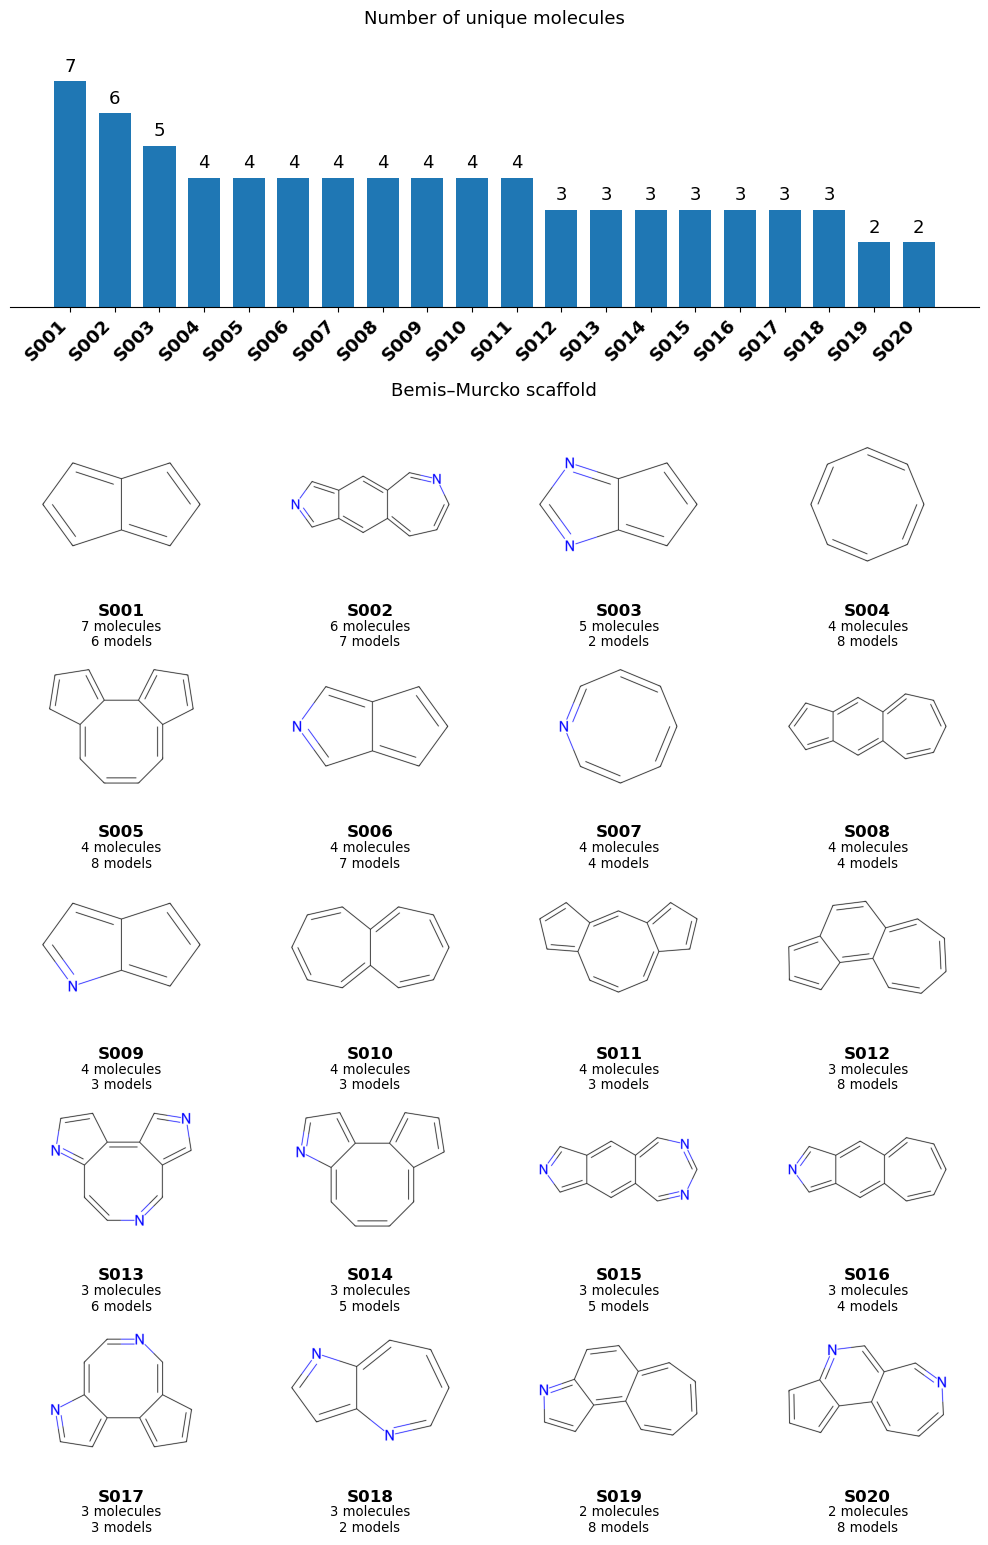

In [11]:
N_SCAFFOLDS_TO_SHOW = 20
USE_GENERIC_SCAFFOLDS = False
SCAFFOLD_OUTPUT_DIR = Path(OUTPUT_DIR if 'OUTPUT_DIR' in globals() else '.')
SCAFFOLD_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
required_columns = {'dataset_index', 'SMILES', 'model'}
if 'membership_long' not in globals():
    raise NameError("The DataFrame 'membership_long' was not found. Run the earlier notebook cells that create membership_long first.")
missing_columns = required_columns - set(membership_long.columns)
if missing_columns:
    raise ValueError(f'membership_long is missing the following required columns: {sorted(missing_columns)}')
structural_occurrences = membership_long[['dataset_index', 'SMILES', 'model']].copy()
structural_occurrences['dataset_index'] = structural_occurrences['dataset_index'].astype(int)
structural_occurrences['SMILES'] = structural_occurrences['SMILES'].astype(str)
valid_rows = []
for row in structural_occurrences.itertuples(index=False):
    mol = Chem.MolFromSmiles(row.SMILES)
    if mol is None:
        print(f'Warning: invalid SMILES skipped: {row.SMILES}')
        continue
    canonical_smiles = Chem.MolToSmiles(mol, canonical=True)
    valid_rows.append({'dataset_index': int(row.dataset_index), 'SMILES': canonical_smiles, 'model': row.model})
valid_occurrences = pd.DataFrame(valid_rows)
if valid_occurrences.empty:
    raise ValueError('No valid molecules were found in membership_long.')
unique_bottom_molecules = valid_occurrences.groupby(['dataset_index', 'SMILES'], as_index=False).agg(n_models=('model', 'nunique'), models=('model', lambda values: '; '.join(sorted(set(values))))).sort_values('dataset_index').reset_index(drop=True)
scaffold_rows = []
invalid_scaffold_count = 0
acyclic_count = 0
for row in unique_bottom_molecules.itertuples(index=False):
    mol = Chem.MolFromSmiles(row.SMILES)
    scaffold_mol = MurckoScaffold.GetScaffoldForMol(mol)
    if scaffold_mol is None or scaffold_mol.GetNumAtoms() == 0:
        scaffold_smiles = '[ACYCLIC]'
        acyclic_count += 1
    else:
        if USE_GENERIC_SCAFFOLDS:
            scaffold_mol = MurckoScaffold.MakeScaffoldGeneric(scaffold_mol)
        scaffold_smiles = Chem.MolToSmiles(scaffold_mol, canonical=True)
        if not scaffold_smiles:
            scaffold_smiles = '[INVALID_SCAFFOLD]'
            invalid_scaffold_count += 1
    scaffold_rows.append({'dataset_index': int(row.dataset_index), 'SMILES': row.SMILES, 'n_models': int(row.n_models), 'models': row.models, 'scaffold_smiles': scaffold_smiles})
scaffold_assignments = pd.DataFrame(scaffold_rows)
scaffold_summary = scaffold_assignments.groupby('scaffold_smiles', as_index=False).agg(molecule_count=('dataset_index', 'nunique'), model_count=('models', lambda values: len({model for value in values for model in value.split('; ')})), models=('models', lambda values: '; '.join(sorted({model for value in values for model in value.split('; ')}))), dataset_indices=('dataset_index', lambda values: '; '.join((str(int(value)) for value in sorted(set(values))))))
n_unique_molecules = scaffold_assignments['dataset_index'].nunique()
scaffold_summary['percentage'] = 100 * scaffold_summary['molecule_count'] / n_unique_molecules
scaffold_summary = scaffold_summary.sort_values(['molecule_count', 'model_count', 'scaffold_smiles'], ascending=[False, False, True]).reset_index(drop=True)
scaffold_summary.insert(0, 'scaffold_id', [f'S{i:03d}' for i in range(1, len(scaffold_summary) + 1)])
scaffold_id_map = dict(zip(scaffold_summary['scaffold_smiles'], scaffold_summary['scaffold_id']))
scaffold_assignments['scaffold_id'] = scaffold_assignments['scaffold_smiles'].map(scaffold_id_map)
scaffold_assignments = scaffold_assignments[['dataset_index', 'SMILES', 'scaffold_id', 'scaffold_smiles', 'n_models', 'models']]
n_scaffolds = len(scaffold_summary)
n_singleton_scaffolds = int((scaffold_summary['molecule_count'] == 1).sum())
largest_scaffold_size = int(scaffold_summary['molecule_count'].max())
largest_scaffold_percentage = float(scaffold_summary.iloc[0]['percentage'])
largest_scaffold_id = scaffold_summary.iloc[0]['scaffold_id']
print('Bemis–Murcko scaffold analysis')
print('--------------------------------')
print(f'Unique bottom-50 molecules: {n_unique_molecules}')
print(f'Unique scaffolds: {n_scaffolds}')
print(f'Singleton scaffolds: {n_singleton_scaffolds}')
print(f'Acyclic molecules: {acyclic_count}')
print(f'Largest scaffold: {largest_scaffold_id}, n = {largest_scaffold_size} ({largest_scaffold_percentage:.1f}%)')
if invalid_scaffold_count > 0:
    print(f'Invalid/empty scaffold assignments: {invalid_scaffold_count}')
display_columns = ['scaffold_id', 'scaffold_smiles', 'molecule_count', 'percentage', 'model_count', 'models']
display(scaffold_summary[display_columns].head(N_SCAFFOLDS_TO_SHOW).style.format({'percentage': '{:.1f}'}))
N_SCAFFOLDS_TO_SHOW = 20
N_GRID_COLUMNS = 4
MOLECULE_IMAGE_SIZE = (500, 360)
SCAFFOLD_ID_FONTSIZE = 12
SCAFFOLD_INFO_FONTSIZE = 9.5
CAPTION_LINESPACING = 1.15
BAR_CHART_HEIGHT = 3.8
GRID_ROW_HEIGHT = 3.0
display_scaffolds = scaffold_summary.loc[scaffold_summary['scaffold_smiles'] != '[ACYCLIC]'].head(N_SCAFFOLDS_TO_SHOW).copy().reset_index(drop=True)
if display_scaffolds.empty:
    raise ValueError('No non-acyclic Bemis–Murcko scaffolds are available for the combined figure.')
n_displayed = len(display_scaffolds)
n_grid_rows = math.ceil(n_displayed / N_GRID_COLUMNS)
draw_options = rdMolDraw2D.MolDrawOptions()
draw_options.baseFontSize = 0.75
draw_options.padding = 0.08
scaffold_image_arrays = []
valid_display_rows = []
for row in display_scaffolds.itertuples(index=False):
    mol = Chem.MolFromSmiles(row.scaffold_smiles)
    if mol is None:
        print(f'Warning: scaffold {row.scaffold_id} could not be drawn and was skipped.')
        continue
    image_object = Draw.MolToImage(mol, size=MOLECULE_IMAGE_SIZE, options=draw_options)
    if isinstance(image_object, Image.Image):
        image_array = np.asarray(image_object.convert('RGB'))
    elif hasattr(image_object, 'data'):
        image_array = np.asarray(Image.open(BytesIO(image_object.data)).convert('RGB'))
    else:
        raise TypeError(f'Unsupported RDKit image type: {type(image_object)}')
    scaffold_image_arrays.append(image_array)
    valid_display_rows.append(row)
if not valid_display_rows:
    raise ValueError('None of the selected scaffolds could be drawn.')
n_displayed = len(valid_display_rows)
n_grid_rows = math.ceil(n_displayed / N_GRID_COLUMNS)
total_figure_height = BAR_CHART_HEIGHT + n_grid_rows * GRID_ROW_HEIGHT
print('height = ', total_figure_height)
fig = plt.figure(figsize=(12.5, total_figure_height))
outer_grid = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[BAR_CHART_HEIGHT, n_grid_rows * GRID_ROW_HEIGHT], hspace=0.2)
bar_ax = fig.add_subplot(outer_grid[0])
bar_labels = [row.scaffold_id for row in valid_display_rows]
bar_values = [int(row.molecule_count) for row in valid_display_rows]
bar_positions = np.arange(len(bar_labels))
bars = bar_ax.bar(bar_positions, bar_values, width=0.72)
bar_ax.set_xticks(bar_positions)
bar_ax.set_xticklabels(bar_labels, rotation=45, ha='right', fontsize=13, fontweight='bold')
bar_ax.set_xlabel('Bemis–Murcko scaffold', fontsize=13, labelpad=12)
bar_ax.set_title('Number of unique molecules', fontsize=13, pad=12)
bar_ax.set_yticks([])
bar_ax.spines['left'].set_visible(False)
bar_ax.spines['top'].set_visible(False)
bar_ax.spines['right'].set_visible(False)
bar_ax.set_ylim(0, max(bar_values) * 1.18)
for bar, value in zip(bars, bar_values):
    bar_ax.text(bar.get_x() + bar.get_width() / 2, value + max(bar_values) * 0.025, str(value), ha='center', va='bottom', fontsize=13)
structure_grid = outer_grid[1].subgridspec(nrows=n_grid_rows, ncols=N_GRID_COLUMNS, hspace=0.35, wspace=0.12)
for panel_index in range(n_grid_rows * N_GRID_COLUMNS):
    row_index = panel_index // N_GRID_COLUMNS
    column_index = panel_index % N_GRID_COLUMNS
    ax = fig.add_subplot(structure_grid[row_index, column_index])
    ax.axis('off')
    if panel_index >= n_displayed:
        continue
    row = valid_display_rows[panel_index]
    image_array = scaffold_image_arrays[panel_index]
    ax.imshow(image_array)
    ax.set_xlim(0, image_array.shape[1])
    ax.set_ylim(image_array.shape[0] * 1.22, 0)
    ax.text(0.5, -0.01, row.scaffold_id, transform=ax.transAxes, ha='center', va='top', fontsize=SCAFFOLD_ID_FONTSIZE, fontweight='bold')
    caption_text = f'{int(row.molecule_count)} molecules\n{int(row.model_count)} models'
    ax.text(0.5, -0.105, caption_text, transform=ax.transAxes, ha='center', va='top', fontsize=SCAFFOLD_INFO_FONTSIZE, linespacing=CAPTION_LINESPACING)
combined_scaffold_figure_path = SCAFFOLD_OUTPUT_DIR / 'figs6.png'
fig.savefig(combined_scaffold_figure_path, dpi=600, bbox_inches='tight', pad_inches=0.08)
plt.show()


## 11. `figs7.png`

The exact Murcko scaffolds are converted to generic scaffolds, grouped by frequency, and displayed as a frequency chart plus a structure grid.


height =  19.4


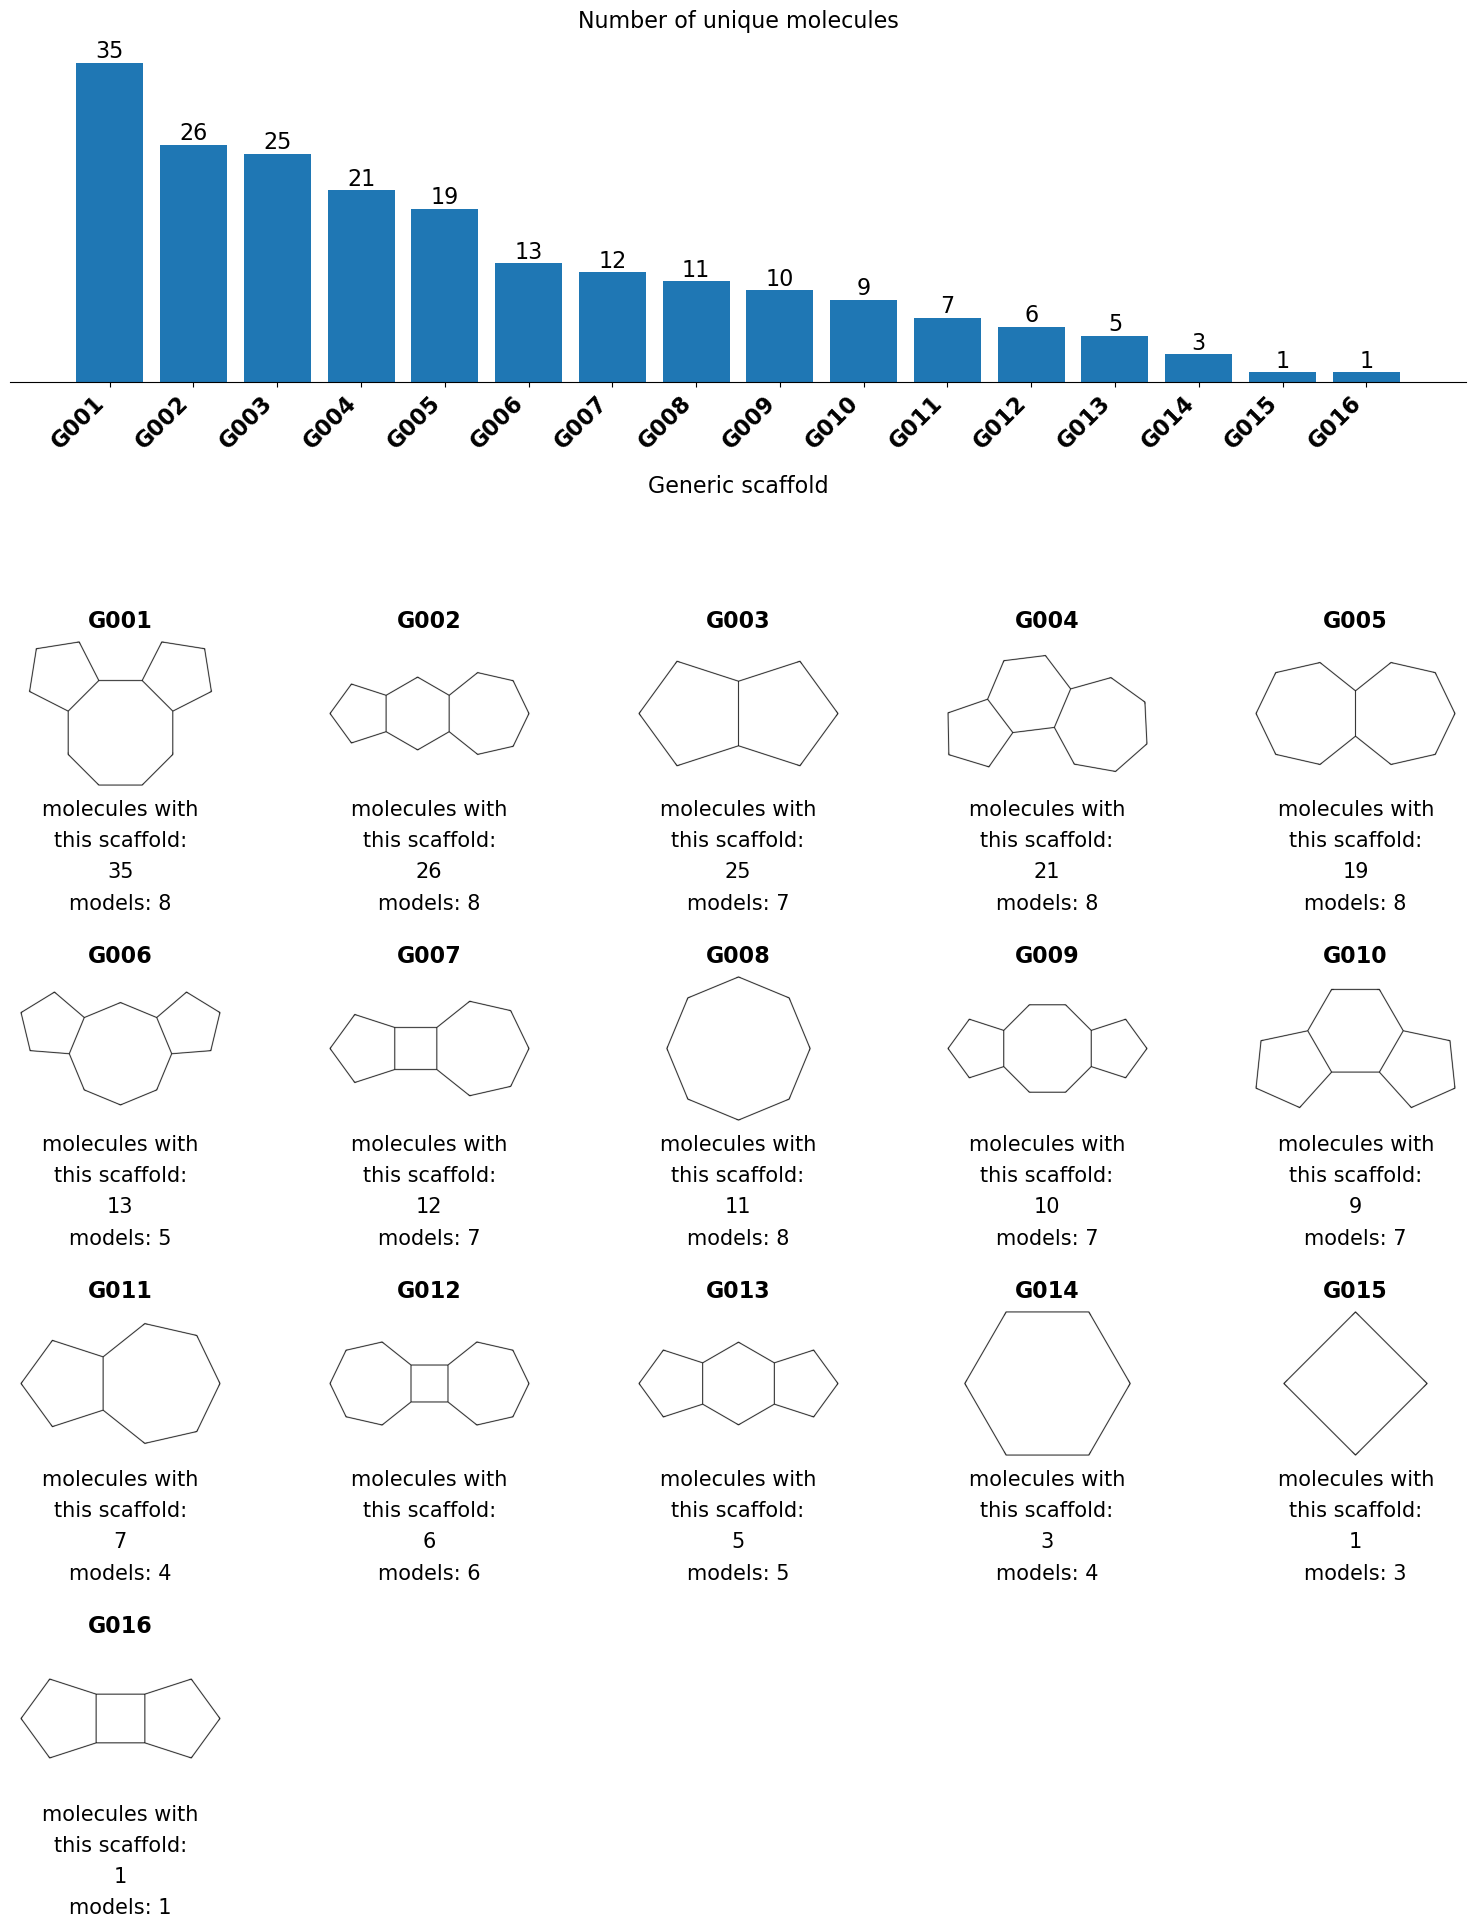

In [12]:
TOP_N_GENERIC_SCAFFOLDS = 20
N_COLUMNS = 5
GENERIC_OUTPUT_DIR = Path('./')
required_columns = {'dataset_index', 'SMILES', 'model'}
missing_columns = required_columns - set(membership_long.columns)
if missing_columns:
    raise ValueError('membership_long is missing required columns: ' + f'{sorted(missing_columns)}')
unique_bottom50_molecules = membership_long[['dataset_index', 'SMILES']].drop_duplicates(subset='dataset_index').copy().reset_index(drop=True)
molecule_model_membership = membership_long.groupby('dataset_index', as_index=False).agg(n_models=('model', 'nunique'), models=('model', lambda values: ', '.join(sorted(set(values)))))
unique_bottom50_molecules = unique_bottom50_molecules.merge(molecule_model_membership, on='dataset_index', how='left')
murcko_smiles_list, generic_smiles_list = ([], [])
for smiles in unique_bottom50_molecules['SMILES']:
    mol = Chem.MolFromSmiles(str(smiles))
    murcko_smiles, generic_smiles = (None, None)
    if mol is not None:
        murcko_scaffold = MurckoScaffold.GetScaffoldForMol(mol)
        if murcko_scaffold is not None and murcko_scaffold.GetNumAtoms() > 0:
            generic_scaffold = MurckoScaffold.MakeScaffoldGeneric(murcko_scaffold)
            if generic_scaffold is not None and generic_scaffold.GetNumAtoms() > 0:
                try:
                    Chem.SanitizeMol(generic_scaffold)
                except Exception:
                    pass
                murcko_smiles = Chem.MolToSmiles(murcko_scaffold, canonical=True)
                generic_smiles = Chem.MolToSmiles(generic_scaffold, canonical=True)
    murcko_smiles_list.append(murcko_smiles)
    generic_smiles_list.append(generic_smiles)
unique_bottom50_molecules['murcko_scaffold_smiles'] = murcko_smiles_list
unique_bottom50_molecules['generic_scaffold_smiles'] = generic_smiles_list
generic_scaffold_assignments = unique_bottom50_molecules.dropna(subset=['generic_scaffold_smiles']).copy()
n_unique_molecules = len(unique_bottom50_molecules)
n_with_generic_scaffold = len(generic_scaffold_assignments)
n_without_generic_scaffold = n_unique_molecules - n_with_generic_scaffold
generic_scaffold_summary = generic_scaffold_assignments.groupby('generic_scaffold_smiles', as_index=False).agg(n_unique_molecules=('dataset_index', 'nunique'), molecule_indices=('dataset_index', lambda values: ', '.join(map(str, sorted(set(values))))))
scaffold_model_membership = generic_scaffold_assignments[['dataset_index', 'generic_scaffold_smiles']].merge(membership_long[['dataset_index', 'model']], on='dataset_index', how='left').drop_duplicates(subset=['generic_scaffold_smiles', 'dataset_index', 'model']).groupby('generic_scaffold_smiles', as_index=False).agg(n_models=('model', 'nunique'), models=('model', lambda values: ', '.join(sorted(set(values)))))
generic_scaffold_summary = generic_scaffold_summary.merge(scaffold_model_membership, on='generic_scaffold_smiles', how='left').sort_values(['n_unique_molecules', 'n_models'], ascending=[False, False]).reset_index(drop=True)
generic_scaffold_summary.insert(0, 'generic_scaffold_id', [f'G{i:03d}' for i in range(1, len(generic_scaffold_summary) + 1)])
generic_scaffold_assignments = generic_scaffold_assignments.merge(generic_scaffold_summary[['generic_scaffold_id', 'generic_scaffold_smiles']], on='generic_scaffold_smiles', how='left')
top_generic_scaffolds = generic_scaffold_summary.head(TOP_N_GENERIC_SCAFFOLDS).copy()
n_displayed = len(top_generic_scaffolds)
if n_displayed == 0:
    raise ValueError('No generic scaffold could be generated.')
scaffold_images = []
for smiles in top_generic_scaffolds['generic_scaffold_smiles']:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        scaffold_images.append(None)
    else:
        Chem.rdDepictor.Compute2DCoords(mol)
        scaffold_images.append(Draw.MolToImage(mol, size=(500, 360), kekulize=False))
n_rows = math.ceil(n_displayed / N_COLUMNS)
figure_height = 5.0 + n_rows * 3.6
print('height = ', figure_height)
fig = plt.figure(figsize=(16, figure_height), constrained_layout=False)
outer_grid = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[1.25, n_rows * 1.15], hspace=0.28)
ax_bar = fig.add_subplot(outer_grid[0])
x_positions = np.arange(n_displayed)
ax_bar.bar(x_positions, top_generic_scaffolds['n_unique_molecules'])
ax_bar.set_xticks(x_positions)
ax_bar.set_xticklabels(top_generic_scaffolds['generic_scaffold_id'], rotation=45, ha='right', fontsize=16, fontweight='bold')
ax_bar.set_xlabel('Generic scaffold', fontsize=16, labelpad=15)
ax_bar.set_title('Number of unique molecules', fontsize=16, pad=14)
ax_bar.set_yticks([])
ax_bar.spines['left'].set_visible(False)
ax_bar.spines['top'].set_visible(False)
ax_bar.spines['right'].set_visible(False)
for position, value in zip(x_positions, top_generic_scaffolds['n_unique_molecules']):
    ax_bar.text(position, value, str(int(value)), ha='center', va='bottom', fontsize=16)
structure_grid = outer_grid[1].subgridspec(nrows=n_rows, ncols=N_COLUMNS, wspace=0.4, hspace=0.48)
for plot_index in range(n_rows * N_COLUMNS):
    row_index = plot_index // N_COLUMNS
    column_index = plot_index % N_COLUMNS
    ax = fig.add_subplot(structure_grid[row_index, column_index])
    ax.axis('off')
    if plot_index >= n_displayed:
        continue
    scaffold_row = top_generic_scaffolds.iloc[plot_index]
    scaffold_image = scaffold_images[plot_index]
    if scaffold_image is not None:
        ax.imshow(scaffold_image)
    ax.set_title(scaffold_row['generic_scaffold_id'], fontsize=16, fontweight='bold', pad=5)
    ax.text(0.5, -0.04, f"molecules with\nthis scaffold:\n{int(scaffold_row['n_unique_molecules'])}\nmodels: {int(scaffold_row['n_models'])}", transform=ax.transAxes, ha='center', va='top', fontsize=15, linespacing=1.7)
fig.subplots_adjust(top=0.96, bottom=0.04, left=0.07, right=0.98)
png_path = GENERIC_OUTPUT_DIR / 'figs7.png'
fig.savefig(png_path, dpi=400, bbox_inches='tight')
plt.show()
